# 0. Load data

In [150]:
import pandas as pd


In [151]:
train = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/Nick/churn_train_cleaned.csv")
#train = pd.read_csv("/Users/nick/Library/CloudStorage/OneDrive-Personal/Programming projects/Team Union 2/Team-Union/datasets/resort_train.csv")
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   GuestID         6954 non-null   int64 
 1   PromoCode       6954 non-null   object
 2   Region          6954 non-null   object
 3   AllInclusive    6954 non-null   int64 
 4   PackageType     6954 non-null   object
 5   VIP             6954 non-null   int64 
 6   RoomService     6954 non-null   int64 
 7   Dining          6954 non-null   int64 
 8   Retail          6954 non-null   int64 
 9   Spa             6954 non-null   int64 
 10  Entertainment   6954 non-null   int64 
 11  LoyaltyPoints   6954 non-null   int64 
 12  SurveyScore     6954 non-null   int64 
 13  DaysSinceEmail  6954 non-null   int64 
 14  BookingChannel  6954 non-null   object
 15  AgeGroup        6954 non-null   object
 16  ReferralSource  6954 non-null   object
 17  Churned         6954 non-null   int64 
 18  SharedRo

In [152]:
#Create X and y variables for modeling

from sklearn.model_selection import train_test_split

X = train.drop(['GuestID', 'Churned'], axis=1)
y = train['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. XGBoost

Test ROC-AUC:        0.816
Best iteration:      429


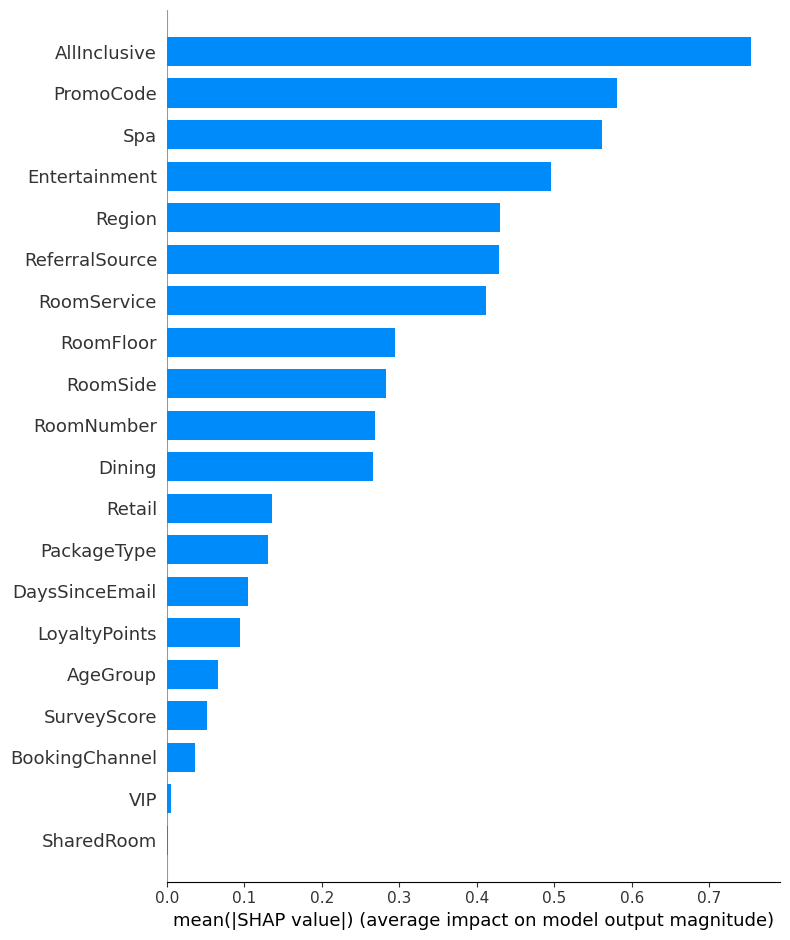

,PromoCode,Region,AllInclusive,PackageType,VIP,RoomService,Dining,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,SharedRoom,RoomFloor,RoomNumber,RoomSide
5487,0,0,1,2,0,0,0,0,0,0,7477,3,161,4,2,15,0,6,1032,0
5489,0,1,1,2,0,0,0,0,0,0,6401,1,19,4,2,17,0,5,952,0
2133,0,0,1,3,0,0,0,0,0,0,9054,5,309,0,1,1,0,6,1394,0
37,0,3,0,2,0,0,0,17,0,793,9884,5,112,3,5,5,0,6,430,0
2063,1,2,1,0,0,0,0,0,0,0,2517,5,25,3,1,5,0,1,181,0


In [153]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import shap

# Class imbalance: scale_pos_weight ≈ neg / pos in your training data
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=neg / pos,
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

# Convert categorical columns to numeric
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

categorical_cols = X_train_encoded.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X_train_encoded[col] = X_train_encoded[col].astype('category').cat.codes
    X_test_encoded[col] = X_test_encoded[col].astype('category').cat.codes

xgb.fit(X_train_encoded, y_train, eval_set=[(X_test_encoded, y_test)], verbose=False)

probs = xgb.predict(X_test_encoded)
print(f"Test ROC-AUC:        {roc_auc_score(y_test, probs):.3f}")
print(f"Best iteration:      {xgb.best_iteration}")

# Explain individual predictions with SHAP — critical for stakeholder trust
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_encoded)
shap.summary_plot(shap_values, X_test_encoded, plot_type="bar")

X_test_encoded.head()

# 2. CatBoost

In [154]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score

# CatBoost handles categoricals natively — just tell it which columns are categorical.
# GuestID is an identifier, drop it from features.
drop_cols = ["GuestID", "Churned"]
X = train.drop(columns=drop_cols)
y = train["Churned"]

cat_features = [c for c in X.columns if X[c].dtype == "object"]
# CatBoost requires categorical columns to have no NaN — fill with a sentinel string.
X[cat_features] = X[cat_features].fillna("missing")

from sklearn.model_selection import train_test_split
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train_cb == 0).sum(), (y_train_cb == 1).sum()

cat = CatBoostClassifier(
    iterations=1000,
    depth=4,
    learning_rate=0.2255611979301099,
    l2_leaf_reg=0.2939990463887897,
    bagging_temperature=0.13866256060046356,
    random_strength=0.02945655242478888,
    border_count=212,
    min_data_in_leaf=52,
    scale_pos_weight=neg / pos,
    eval_metric="AUC",
    early_stopping_rounds=50,
    random_seed=42,
    verbose=False,
)

train_pool = Pool(X_train_cb, y_train_cb, cat_features=cat_features)
test_pool = Pool(X_test_cb, y_test_cb, cat_features=cat_features)

cat.fit(train_pool, eval_set=test_pool)

probs = cat.predict(X_test_cb)
print(f"Test ROC-AUC:        {roc_auc_score(y_test_cb, probs):.3f}")
print(f"Best iteration:      {cat.get_best_iteration()}")

#use scitkit-learn classification report to get precision, recall, f1-score, and support for the test set predictions
from sklearn.metrics import classification_report
y_pred = cat.predict(X_test_cb)
print(classification_report(y_test_cb, y_pred))

# Feature importance
import pandas as pd
fi = pd.DataFrame({
    "feature": X_train_cb.columns,
    "importance": cat.get_feature_importance(train_pool),
}).sort_values("importance", ascending=False)
print(fi.to_string(index=False))

Test ROC-AUC:        0.836
Best iteration:      84
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       690
           1       0.86      0.81      0.83       701

    accuracy                           0.84      1391
   macro avg       0.84      0.84      0.84      1391
weighted avg       0.84      0.84      0.84      1391

       feature  importance
           Spa   16.615767
 Entertainment   13.936160
  AllInclusive   12.967166
        Region   10.385299
ReferralSource    7.608656
   RoomService    7.391299
    RoomNumber    6.308871
        Dining    6.289600
     PromoCode    6.139460
     RoomFloor    3.413520
        Retail    3.287940
      RoomSide    2.473992
 LoyaltyPoints    0.854128
DaysSinceEmail    0.692125
   PackageType    0.689899
      AgeGroup    0.624147
   SurveyScore    0.316337
BookingChannel    0.005635
    SharedRoom    0.000000
           VIP    0.000000


In [155]:
import optuna
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split

# CatBoost handles categoricals natively — just tell it which columns are categorical.
drop_cols = ["GuestID", "Churned"]
X = train.drop(columns=drop_cols)
y = train["Churned"]

cat_features = [c for c in X.columns if X[c].dtype == "object"]
# CatBoost requires categorical columns to have no NaN — fill with a sentinel string.
X[cat_features] = X[cat_features].fillna("missing")

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = (y_train_cb == 0).sum(), (y_train_cb == 1).sum()
scale_pos_weight = neg / pos


def objective(trial):
    params = {
        "iterations": 1000,
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-2, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "AUC",
        "early_stopping_rounds": 50,
        "random_seed": 42,
        "verbose": False,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_cb, y_train_cb)):
        X_tr, X_va = X_train_cb.iloc[tr_idx], X_train_cb.iloc[va_idx]
        y_tr, y_va = y_train_cb.iloc[tr_idx], y_train_cb.iloc[va_idx]

        model = CatBoostClassifier(**params)
        model.fit(
            Pool(X_tr, y_tr, cat_features=cat_features),
            eval_set=Pool(X_va, y_va, cat_features=cat_features),
        )
        proba = model.predict(X_va)
        scores.append(roc_auc_score(y_va, proba))

        trial.report(sum(scores) / len(scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return sum(scores) / len(scores)


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best CV ROC-AUC: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Refit best model on full training set, evaluate on held-out test set
best_params = {
    **study.best_params,
    "iterations": 1000,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "AUC",
    "early_stopping_rounds": 50,
    "random_seed": 42,
    "verbose": False,
}

train_pool = Pool(X_train_cb, y_train_cb, cat_features=cat_features)
test_pool = Pool(X_test_cb, y_test_cb, cat_features=cat_features)

cat = CatBoostClassifier(**best_params)
cat.fit(train_pool, eval_set=test_pool)

proba_test = cat.predict(X_test_cb)
y_pred = cat.predict(X_test_cb)
print(f"\nTest ROC-AUC:   {roc_auc_score(y_test_cb, proba_test):.3f}")
print(f"Best iteration: {cat.get_best_iteration()}")
print(classification_report(y_test_cb, y_pred))

fi = pd.DataFrame({
    "feature": X_train_cb.columns,
    "importance": cat.get_feature_importance(train_pool),
}).sort_values("importance", ascending=False)
print(fi.to_string(index=False))

[I 2026-05-21 15:58:27,183] A new study created in memory with name: no-name-6675da5c-909e-48a5-88ac-9f0a97dd7185


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-21 15:58:29,064] Trial 0 finished with value: 0.8348556088768625 and parameters: {'depth': 6, 'learning_rate': 0.22648248189516842, 'l2_leaf_reg': 1.5702970884055385, 'bagging_temperature': 0.5986584841970366, 'random_strength': 0.004207988669606638, 'border_count': 66, 'min_data_in_leaf': 6}. Best is trial 0 with value: 0.8348556088768625.
[I 2026-05-21 15:58:45,326] Trial 1 finished with value: 0.836879652621543 and parameters: {'depth': 10, 'learning_rate': 0.030834348179355788, 'l2_leaf_reg': 1.3311216080736885, 'bagging_temperature': 0.020584494295802447, 'random_strength': 7.5794799533480015, 'border_count': 218, 'min_data_in_leaf': 22}. Best is trial 1 with value: 0.836879652621543.
[I 2026-05-21 15:58:54,488] Trial 2 finished with value: 0.8202736044885757 and parameters: {'depth': 5, 'learning_rate': 0.002846526357761094, 'l2_leaf_reg': 0.08179499475211674, 'bagging_temperature': 0.5247564316322378, 'random_strength': 0.05342937261279776, 'border_count': 97, 'min_da